# Lab 4.3 — Build a Production Multi-Turn Chatbot with Memory & Tool Use
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 4 — Thursday**

> **Scenario:** You are the founding engineer at a startup called CampusBot.
> CampusBot is being deployed at Chitkara University to answer student queries
> 24/7: exam schedules, hostel fees, placement statistics, library timings, and more.
>
> Simple Q&A is not enough. Students ask follow-up questions that reference
> earlier messages. They ask for live information (today's mess menu, tomorrow's
> events). They want calculations ("if I scored X in internals, what do I need
> in finals?"). A real chatbot needs: **conversation memory**, **tool use**
> (calling functions to fetch live data), and **context management**
> (staying within the LLM's token limit across a long conversation).

**Objective:** Build a complete multi-turn chatbot from scratch.
Implement rolling conversation memory with token budget management.
Add three callable tools (calculator, knowledge base lookup, mock live data).
Implement a tool-calling loop. Measure context window utilisation.
Build an interactive Colab widget for live conversation.

---
### This lab runs entirely on Google Colab — no cloud credentials needed

*(A stronger LLM backend gives much better tool-calling — highly recommended for this lab)*

**Learning outcomes:**
- Understand the multi-turn conversation format (messages array)
- Implement sliding-window memory to stay within the context budget
- Build tool definitions in OpenAI function-calling format
- Write a tool-dispatch loop that handles multi-step tool invocations
- Measure and visualise token usage across a conversation
- Build an interactive chat widget with `ipywidgets`
- Understand when tool-calling beats RAG and when RAG beats tool-calling


## Background — Architecture of a Production Chatbot

### What makes a chatbot 'multi-turn'?

A single LLM call is stateless — it has no memory of previous calls.
Multi-turn behaviour is created by the **application layer**: you maintain
a list of messages and send the *entire conversation history* on every call.

```
Turn 1:  Send [system, user_1]                 → assistant_1
Turn 2:  Send [system, user_1, assistant_1, user_2] → assistant_2
Turn 3:  Send [system, user_1, a_1, user_2, a_2, user_3] → assistant_3
```

The LLM 'remembers' previous turns only because you send them in the context.

### The context window problem

GPT-3.5-turbo has a 16K token context. GPT-4o has 128K.
A long conversation will eventually exceed this limit.
**Solutions (from simplest to most sophisticated):**

| Strategy | How it works | Trade-off |
|----------|-------------|----------|
| **Sliding window** | Keep only the last N messages | Simple; may drop important context |
| **Summarise-and-compress** | Replace old turns with a summary | Preserves key facts; adds latency |
| **Selective retention** | Keep messages tagged as 'important' | Complex; requires scoring |
| **RAG for history** | Embed old turns; retrieve relevant ones | Best recall; highest complexity |

### Tool use (function calling)

Tool use allows the LLM to request that your application run a function and
return the result, which the LLM then incorporates into its response.

```
User:  'What is today's mess menu?'
LLM:   {tool_call: get_mess_menu(day='today')}
App:   runs get_mess_menu() → {'lunch': 'Dal rice, sabzi, curd'}
LLM:   'Today's lunch is Dal rice, sabzi, and curd.'
```

This is more powerful than RAG for *dynamic* data (menus, live schedules, calculations)
because the data is fetched fresh on demand, not pre-indexed.


## Task 1 — Configure backend and set up the CampusBot knowledge base

We create a structured knowledge base for Chitkara University CampusBot.
This covers the most common student queries so the chatbot always has
accurate, specific answers rather than generic hedging.


In [1]:
# ── Backend configuration ────────────────────────────────────────────────
USE_AZURE = False
AZURE_ENDPOINT   = 'https://YOUR-RESOURCE.openai.azure.com/'
AZURE_KEY        = 'YOUR_KEY_HERE'
AZURE_DEPLOYMENT = 'gpt-35-turbo'
AZURE_API_VERSION= '2024-02-01'

USE_HF    = False
HF_TOKEN  = 'hf_YOUR_TOKEN_HERE'
HF_MODEL  = 'mistralai/Mistral-7B-Instruct-v0.3'

USE_LOCAL = True   # GPT-2 fallback

active = [n for n,f in [('Azure',USE_AZURE),('HuggingFace',USE_HF),('Local GPT-2',USE_LOCAL)] if f]
print(f'Backend: {active[0] if len(active)==1 else str(active)}')
if 'Local GPT-2' in active:
    print('  NOTE: GPT-2 has limited multi-turn ability. Tool use and memory concepts still work.')
    print('  For best multi-turn experience use Azure (gpt-35-turbo) or HuggingFace (Mistral-7B).')


Backend: Local GPT-2
  NOTE: GPT-2 has limited multi-turn ability. Tool use and memory concepts still work.
  For best multi-turn experience use Azure (gpt-35-turbo) or HuggingFace (Mistral-7B).


In [2]:
!pip install openai requests transformers torch tiktoken ipywidgets --quiet

import json, time, re, math, datetime, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── CampusBot structured knowledge base ──────────────────────────────────
# Stored as nested dict — used by the knowledge_lookup tool
CAMPUS_KB = {
    'academic_calendar': {
        'semester_start'  : 'July 22, 2025',
        'mid_semester_exams': 'September 15-20, 2025',
        'end_semester_exams': 'November 24 - December 5, 2025',
        'winter_break'    : 'December 20, 2025 - January 5, 2026',
        'result_declaration': 'January 15, 2026',
    },
    'hostel_fees': {
        'single_ac'       : 'Rs 85,000 per semester (including mess)',
        'double_ac'       : 'Rs 62,000 per semester (including mess)',
        'double_non_ac'   : 'Rs 45,000 per semester (including mess)',
        'triple_non_ac'   : 'Rs 38,000 per semester (including mess)',
        'payment_deadline': '10th of every month for monthly plans',
        'deposit'         : 'Rs 10,000 refundable security deposit',
    },
    'library': {
        'weekday_hours'   : '8:00 AM – 11:00 PM',
        'weekend_hours'   : '9:00 AM – 9:00 PM',
        'exam_hours'      : '7:00 AM – 12:00 AM (midnight) during exam weeks',
        'e_resources'     : 'IEEE Xplore, ACM Digital Library, Springer, Elsevier',
        'book_borrowing'  : '3 books for 14 days; renewable once online',
        'fine'            : 'Rs 2 per day per book for late returns',
    },
    'placement_stats': {
        'year'            : '2024-25',
        'placement_rate'  : '89% of eligible B.Tech students placed',
        'highest_package' : 'Rs 42 LPA (Microsoft, 2 students)',
        'average_package' : 'Rs 8.4 LPA',
        'median_package'  : 'Rs 6.8 LPA',
        'top_recruiters'  : 'TCS, Infosys, Wipro, Amazon, Microsoft, Capgemini, Accenture',
        'total_offers'    : '1,847 offer letters to 1,203 eligible students',
    },
    'exam_rules': {
        'passing_marks'   : '40% in each component (internal + external)',
        'internal_weight' : '40 marks (continuous assessment)',
        'external_weight' : '60 marks (end-semester exam)',
        'attendance_min'  : '75% attendance mandatory to appear in exam',
        'backlog_exam'    : 'Supplementary exams conducted in January/June',
        'grading_scale'   : 'O(>90), A+(80-89), A(70-79), B+(60-69), B(50-59), C(40-49), F(<40)',
    },
    'clubs': {
        'technical'       : 'Coding Club, Robotics Club, AI/ML Club, Cybersecurity Club',
        'cultural'        : 'Drama Society, Music Club, Dance Troupe, Photography Club',
        'sports'          : 'Cricket, Football, Basketball, Badminton, Chess',
        'registration'    : 'First two weeks of each semester via student portal',
    },
    'facilities': {
        'clinic'          : 'University Health Centre: Mon-Sat 9AM-6PM, emergency 24/7',
        'atm'             : 'SBI ATM near admin block, HDFC ATM near hostel C block',
        'gym'             : '6:00 AM – 9:00 PM daily, Rs 500/semester for students',
        'cafeteria'       : '7:30 AM – 10:00 PM, vegetarian and non-vegetarian options',
        'wifi'            : 'Campus-wide WiFi (SSID: Chitkara-Student), 50 Mbps per user',
    },
}

print(f'Knowledge base loaded: {len(CAMPUS_KB)} categories')
for cat, entries in CAMPUS_KB.items():
    print(f'  {cat:<25}: {len(entries)} entries')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00
Knowledge base loaded: 7 categories
  academic_calendar        : 5 entries
  hostel_fees              : 6 entries
  library                  : 6 entries
  placement_stats          : 7 entries
  exam_rules               : 6 entries
  clubs                    : 4 entries
  facilities               : 5 entries


## Task 2 — Build the three callable tools

We build three tools that CampusBot can call when the LLM decides it needs
data or computation that is not in its training knowledge:

### Tool 1 — `knowledge_lookup(category, key)`
Retrieves specific facts from the structured CampusBot knowledge base.
The LLM calls this when a student asks about hostel fees, placement stats, etc.

### Tool 2 — `grade_calculator(internal_marks, target_grade)`
Computes what a student needs in the end-semester exam to achieve a target grade.
Based on the 40/60 internal/external weighting. Pure computation — no LLM needed.

### Tool 3 — `get_live_info(info_type)`
Simulates calling a live API for dynamic data: today's mess menu, tomorrow's events,
current wifi status. In production this would call a real university REST API;
here we return realistic mock data based on today's date.

### OpenAI function-calling format
Tools are described in JSON Schema format. The LLM reads this schema and decides
when to call each tool and with what arguments.


In [3]:
# ── Tool implementations ─────────────────────────────────────────────────

def knowledge_lookup(category: str, key: str = None) -> dict:
    """
    Look up information from the CampusBot knowledge base.
    If key is None, returns all entries in the category.
    Returns a dict: {success: bool, data: ..., error: str}
    """
    cat = category.lower().replace(' ', '_').replace('-', '_')
    if cat not in CAMPUS_KB:
        # Try partial match
        matches = [k for k in CAMPUS_KB if cat in k or k in cat]
        if matches:
            cat = matches[0]
        else:
            return {'success': False, 'error': f'Category "{category}" not found. '
                    f'Available: {list(CAMPUS_KB.keys())}'}
    cat_data = CAMPUS_KB[cat]
    if key:
        k = key.lower().replace(' ', '_')
        if k in cat_data:
            return {'success': True, 'category': cat, 'key': k, 'value': cat_data[k]}
        # Partial match on key
        matches = {mk: mv for mk, mv in cat_data.items() if k in mk or mk in k}
        if matches:
            return {'success': True, 'category': cat, 'matches': matches}
        return {'success': False, 'error': f'Key "{key}" not found in {cat}. '
                f'Available keys: {list(cat_data.keys())}'}
    return {'success': True, 'category': cat, 'data': cat_data}


def grade_calculator(internal_marks: float, target_grade: str = 'B+') -> dict:
    """
    Calculate required end-semester marks to achieve a target grade.
    Internal: 40 marks total weight. External: 60 marks total weight.
    Total = (internal/40)*40 + (external/60)*60
    Returns required external marks and whether it's achievable.
    """
    grade_thresholds = {'O': 90, 'A+': 80, 'A': 70, 'B+': 60, 'B': 50, 'C': 40}
    tgt = target_grade.upper().strip()
    if tgt not in grade_thresholds:
        return {'success': False,
                'error': f'Unknown grade "{target_grade}". Use: {list(grade_thresholds.keys())}'}
    if not (0 <= internal_marks <= 40):
        return {'success': False, 'error': 'internal_marks must be between 0 and 40.'}

    threshold    = grade_thresholds[tgt]
    # Total score = internal_component + external_component
    # internal_component = (internal_marks / 40) * 40 = internal_marks
    # external_component = (external_marks / 60) * 60 = external_marks
    # Total = internal_marks + external_marks  (both on 40 and 60 scales respectively)
    # To get total >= threshold (out of 100): external >= threshold - internal_marks
    required_external = threshold - internal_marks
    achievable        = (0 <= required_external <= 60)

    current_max  = internal_marks + 60  # best possible if external = 60
    current_min  = internal_marks + 0   # worst possible if external = 0

    return {
        'success'          : True,
        'internal_marks'   : internal_marks,
        'target_grade'     : tgt,
        'grade_threshold'  : threshold,
        'required_external': max(0, required_external),
        'achievable'       : achievable,
        'current_max_score': current_max,
        'note'             : (
            f'You need {max(0, required_external):.1f}/60 in end-semester to get {tgt}. '
            + ('This is achievable.' if achievable else
               'This is NOT achievable — maximum possible score is below target.')
        )
    }


def get_live_info(info_type: str) -> dict:
    """
    Fetch simulated live campus information.
    info_type: 'mess_menu', 'events', 'wifi_status', 'library_seats'
    """
    today     = datetime.datetime.now()
    day_name  = today.strftime('%A')
    date_str  = today.strftime('%d %B %Y')
    hour      = today.hour

    MESS_MENUS = {
        'Monday'   : {'breakfast':'Poha, chai, banana','lunch':'Dal tadka, roti, rice, raita','dinner':'Paneer butter masala, roti, rice, salad'},
        'Tuesday'  : {'breakfast':'Idli sambar, coconut chutney','lunch':'Rajma, rice, roti, pickle','dinner':'Kadai sabzi, roti, dal, rice'},
        'Wednesday': {'breakfast':'Paratha, curd, chai','lunch':'Chana masala, rice, roti, raita','dinner':'Mix veg, roti, rice, dal fry'},
        'Thursday' : {'breakfast':'Upma, banana, chai','lunch':'Aloo gobi, roti, rice, curd','dinner':'Dal makhani, roti, rice, salad'},
        'Friday'   : {'breakfast':'Bread butter jam, boiled egg, chai','lunch':'Palak paneer, roti, rice, raita','dinner':'Special biryani, raita, salad'},
        'Saturday' : {'breakfast':'Chole bhature, chai','lunch':'Kadhi pakora, rice, roti, achar','dinner':'Veg pulao, dal, raita, sweet'},
        'Sunday'   : {'breakfast':'Puri sabzi, halwa, chai','lunch':'Special thali: 3 sabzi, dal, rice, roti, sweet','dinner':'Pasta/noodles special, soup, salad'},
    }

    if info_type == 'mess_menu':
        menu = MESS_MENUS.get(day_name, MESS_MENUS['Monday'])
        next_day = (today + datetime.timedelta(days=1)).strftime('%A')
        tomorrow_menu = MESS_MENUS.get(next_day, MESS_MENUS['Monday'])
        return {'success': True, 'today': date_str, 'day': day_name,
                'today_menu': menu, 'tomorrow_menu': tomorrow_menu}

    elif info_type == 'events':
        events = [
            {'date': date_str, 'event': 'AI/ML Club weekly session', 'venue': 'Lab 304, Block B', 'time': '5:00 PM'},
            {'date': (today+datetime.timedelta(1)).strftime('%d %B'), 'event': 'Career Talk: Accenture campus hiring', 'venue': 'Auditorium', 'time': '11:00 AM'},
            {'date': (today+datetime.timedelta(2)).strftime('%d %B'), 'event': 'Intramural Cricket: CSE vs ECE', 'venue': 'Sports Ground', 'time': '4:00 PM'},
        ]
        return {'success': True, 'upcoming_events': events}

    elif info_type == 'wifi_status':
        status = 'operational' if random.random() > 0.1 else 'degraded (maintenance 2-4 AM)'
        speed  = random.randint(35, 50)
        return {'success': True, 'status': status,
                'current_speed_mbps': speed, 'checked_at': today.strftime('%H:%M')}

    elif info_type == 'library_seats':
        total     = 400
        occupied  = random.randint(80, 350)
        available = total - occupied
        return {'success': True, 'total_seats': total,
                'available': available, 'occupancy_pct': round(100*occupied/total)}
    else:
        return {'success': False,
                'error': f'Unknown info_type "{info_type}". Use: mess_menu, events, wifi_status, library_seats'}


# ── Test all three tools ──────────────────────────────────────────────────
print('TOOL TESTS')
print('='*55)

print('knowledge_lookup("hostel_fees"):')
r = knowledge_lookup('hostel_fees')
print(f'  {json.dumps(r, indent=4)[:300]}')

print('\ngrade_calculator(internal_marks=28, target_grade="A"):')
r = grade_calculator(28, 'A')
print(f'  {json.dumps(r, indent=4)}')

print('\nget_live_info("mess_menu"):')
r = get_live_info('mess_menu')
print(f'  Today ({r["day"]}): {r["today_menu"]}')


TOOL TESTS
knowledge_lookup("hostel_fees"):
  {
    "success": true,
    "category": "hostel_fees",
    "data": {
        "single_ac": "Rs 85,000 per semester (including mess)",
        "double_ac": "Rs 62,000 per semester (including mess)",
        "double_non_ac": "Rs 45,000 per semester (including mess)",
        "triple_non_ac": "Rs 38,000 

grade_calculator(internal_marks=28, target_grade="A"):
  {
    "success": true,
    "internal_marks": 28,
    "target_grade": "A",
    "grade_threshold": 70,
    "required_external": 42,
    "achievable": true,
    "current_max_score": 88,
    "note": "You need 42.0/60 in end-semester to get A. This is achievable."
}

get_live_info("mess_menu"):
  Today (Wednesday): {'breakfast': 'Paratha, curd, chai', 'lunch': 'Chana masala, rice, roti, raita', 'dinner': 'Mix veg, roti, rice, dal fry'}


## Task 3 — Build the memory manager and context-aware LLM wrapper

### Token budget management

The LLM has a finite context window. As the conversation grows, we must decide
which messages to keep. We implement a **sliding window with system prompt protection**:

```
Budget = 3000 tokens (conservative limit for Colab demo)
Always keep: system prompt (~300 tokens)
Always keep: last 2 turns (current question + previous answer)
Fill remaining budget: oldest → newest until budget exhausted
```

### Token counting
We use `tiktoken` — OpenAI's tokenizer — for accurate token counting.
For GPT-2/HuggingFace backends, we use word-count approximation (1 word ≈ 1.3 tokens).


In [4]:
try:
    import tiktoken
    enc_tok = tiktoken.encoding_for_model('gpt-3.5-turbo')
    def count_tokens(text):
        return len(enc_tok.encode(text))
    print('tiktoken loaded — accurate token counting enabled')
except Exception:
    def count_tokens(text):
        return int(len(text.split()) * 1.3)   # approximation
    print('Using word-count approximation for token counting')

# ── Memory manager ────────────────────────────────────────────────────────
class ConversationMemory:
    """
    Manages the conversation history with a token budget.
    Implements sliding-window truncation to stay within the context limit.
    """
    def __init__(self, system_prompt: str, token_budget: int = 3000):
        self.system_prompt = system_prompt
        self.token_budget  = token_budget
        self.history       = []          # list of {role, content} dicts
        self.turn_count    = 0
        self.tokens_used_log = []        # (turn, token_count) for visualisation
        self._sys_tokens   = count_tokens(system_prompt)

    def add_turn(self, role: str, content: str):
        """Add a message to history."""
        self.history.append({'role': role, 'content': content})
        if role == 'assistant':
            self.turn_count += 1
            self.tokens_used_log.append((self.turn_count, self._count_context_tokens()))

    def get_messages(self) -> list:
        """Return the messages list truncated to fit within the token budget."""
        # Always include system prompt
        messages = [{'role': 'system', 'content': self.system_prompt}]
        budget_left = self.token_budget - self._sys_tokens

        # Walk history newest-first, adding messages until budget is exhausted
        selected = []
        for msg in reversed(self.history):
            msg_tokens = count_tokens(msg['content']) + 10  # +10 for message overhead
            if budget_left >= msg_tokens:
                selected.append(msg)
                budget_left -= msg_tokens
            else:
                break  # can't fit any more history

        messages.extend(reversed(selected))
        return messages

    def _count_context_tokens(self) -> int:
        total = self._sys_tokens
        for msg in self.history:
            total += count_tokens(msg['content']) + 10
        return total

    def get_stats(self) -> dict:
        msgs = self.get_messages()
        ctx_tokens = sum(count_tokens(m['content']) for m in msgs)
        return {
            'total_turns'     : self.turn_count,
            'history_messages': len(self.history),
            'context_messages': len(msgs) - 1,   # exclude system
            'context_tokens'  : ctx_tokens,
            'budget'          : self.token_budget,
            'utilisation_pct' : round(100 * ctx_tokens / self.token_budget, 1),
        }

print('ConversationMemory class ready.')
print()

# ── Quick memory test ─────────────────────────────────────────────────────
test_mem = ConversationMemory('You are a test assistant.', token_budget=200)
for i in range(6):
    test_mem.add_turn('user',      f'This is test user message number {i+1}.')
    test_mem.add_turn('assistant', f'This is test assistant reply number {i+1}.')

stats = test_mem.get_stats()
print(f'After 6 turns, 200-token budget:')
print(f'  Total history messages : {stats["history_messages"]}')
print(f'  Messages in context    : {stats["context_messages"]}  (truncated to fit budget)')
print(f'  Context tokens used    : {stats["context_tokens"]}')
print(f'  Budget utilisation     : {stats["utilisation_pct"]}%')


tiktoken loaded — accurate token counting enabled
ConversationMemory class ready.

After 6 turns, 200-token budget:
  Total history messages : 12
  Messages in context    : 10  (truncated to fit budget)
  Context tokens used    : 96
  Budget utilisation     : 48.0%


## Task 4 — Build the tool-calling dispatch loop

The tool-calling loop follows this pattern for every turn:

```
1. User sends message
2. Add to memory
3. Call LLM with conversation + tool definitions
4. If LLM returns a tool_call:
     a. Parse the tool name and arguments
     b. Execute the tool function in Python
     c. Add tool result to conversation
     d. Call LLM again with the tool result
     e. Repeat until LLM returns a regular text response
5. Add LLM response to memory
6. Return response to user
```

**Note on backends:**
- **Azure GPT-3.5/GPT-4o:** Full native tool-calling via the `tools` parameter
- **HuggingFace Mistral:** We simulate tool-calling with a structured prompt approach
- **Local GPT-2:** We parse tool requests from the model's text output using regex

The simulation approach for non-Azure backends is less reliable but demonstrates
the exact same architectural pattern used in production systems.


In [5]:
# ── Tool definitions in OpenAI function-calling schema ───────────────────
TOOL_DEFINITIONS = [
    {
        'type': 'function',
        'function': {
            'name': 'knowledge_lookup',
            'description': (
                'Look up official Chitkara University information: hostel fees, '
                'exam rules, placement stats, library hours, clubs, facilities, '
                'academic calendar. Use this for any factual campus query.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'category': {
                        'type': 'string',
                        'description': 'Category name. One of: academic_calendar, hostel_fees, '
                                       'library, placement_stats, exam_rules, clubs, facilities',
                    },
                    'key': {
                        'type': 'string',
                        'description': 'Specific field within the category (optional). '
                                       'Leave empty to get all fields in the category.',
                    },
                },
                'required': ['category'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'grade_calculator',
            'description': (
                'Calculate what marks a student needs in the end-semester exam '
                'to achieve a target grade, given their internal assessment marks. '
                'Internal marks are out of 40; end-semester is out of 60.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'internal_marks': {
                        'type': 'number',
                        'description': 'Student internal marks out of 40 (e.g., 28.5)',
                    },
                    'target_grade': {
                        'type': 'string',
                        'description': 'Target grade: O, A+, A, B+, B, C',
                    },
                },
                'required': ['internal_marks', 'target_grade'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'get_live_info',
            'description': (
                'Fetch live campus information: today mess menu, upcoming events, '
                'wifi status, or library seat availability. '
                'Use for any real-time campus data requests.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'info_type': {
                        'type': 'string',
                        'enum': ['mess_menu', 'events', 'wifi_status', 'library_seats'],
                        'description': 'Type of live information to fetch',
                    },
                },
                'required': ['info_type'],
            },
        },
    },
]

TOOL_DISPATCH = {
    'knowledge_lookup' : knowledge_lookup,
    'grade_calculator' : grade_calculator,
    'get_live_info'    : get_live_info,
}

print(f'Tool definitions registered: {[t["function"]["name"] for t in TOOL_DEFINITIONS]}')


Tool definitions registered: ['knowledge_lookup', 'grade_calculator', 'get_live_info']


In [6]:
# ── CampusBot system prompt ───────────────────────────────────────────────
CAMPUSBOT_SYSTEM = """\
You are CampusBot, the official AI assistant for Chitkara University students.
You are helpful, friendly, and accurate.

You have access to three tools:
1. knowledge_lookup — for official university facts (fees, exams, placements, etc.)
2. grade_calculator — to compute required exam scores for a target grade
3. get_live_info — for real-time data (today's mess menu, events, wifi, library seats)

RULES:
- Always use a tool when the question requires specific campus data.
- Never guess fees, dates, or statistics — always look them up.
- Be concise but complete. Answer in 3-5 sentences unless more detail is needed.
- Address the student by name if they have introduced themselves.
- If you cannot find information, say so honestly and suggest they contact the registrar.\
"""

# ── Tool-calling LLM wrapper ──────────────────────────────────────────────
_local_gen = None

def campusbot_call(messages: list, max_tokens: int = 300) -> dict:
    """
    Call LLM with tool support. Returns:
      {'content': str, 'tool_calls': list or None, 'raw': dict}
    For non-Azure backends, simulates tool calling via structured prompting.
    """
    if USE_AZURE:
        from openai import AzureOpenAI
        client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=AZURE_KEY,
                             api_version=AZURE_API_VERSION)
        resp = client.chat.completions.create(
            model=AZURE_DEPLOYMENT,
            messages=messages,
            tools=TOOL_DEFINITIONS,
            tool_choice='auto',
            temperature=0.3,
            max_tokens=max_tokens,
        )
        msg = resp.choices[0].message
        tool_calls = None
        if msg.tool_calls:
            tool_calls = [{
                'id'      : tc.id,
                'name'    : tc.function.name,
                'args_str': tc.function.arguments,
            } for tc in msg.tool_calls]
        return {'content': msg.content or '', 'tool_calls': tool_calls}

    # ── Non-Azure: inject tool schema into system prompt and parse output ──
    tool_desc = '\n'.join(
        f'- {t["function"]["name"]}: {t["function"]["description"][:100]}'
        for t in TOOL_DEFINITIONS
    )
    tool_instruction = (
        f'\n\nYou have these tools: {tool_desc}\n'
        'To call a tool, respond ONLY with: TOOL_CALL: tool_name({"arg": value})\n'
        'Otherwise respond normally in plain text.'
    )
    aug_messages = list(messages)
    aug_messages[0] = {'role': 'system',
                       'content': messages[0]['content'] + tool_instruction}

    if USE_HF:
        import requests as req
        sys_content = aug_messages[0]['content']
        conv_text   = '\n'.join(
            f"{m['role'].capitalize()}: {m['content']}"
            for m in aug_messages[1:]
        )
        prompt = f'[INST] {sys_content}\n\nConversation so far:\n{conv_text}\nAssistant: [/INST]'
        r = req.post(f'https://api-inference.huggingface.co/models/{HF_MODEL}',
                     headers={'Authorization': f'Bearer {HF_TOKEN}'},
                     json={'inputs': prompt,
                           'parameters': {'max_new_tokens': max_tokens,
                                          'temperature': 0.3,
                                          'return_full_text': False}},
                     timeout=60)
        data = r.json()
        text = data[0]['generated_text'].strip() if isinstance(data, list) else str(data)
    else:  # GPT-2
        global _local_gen
        if _local_gen is None:
            from transformers import pipeline as hp
            print('Loading GPT-2...')
            _local_gen = hp('text-generation', model='gpt2', device=-1)
        sys_content = aug_messages[0]['content']
        last_user   = next((m['content'] for m in reversed(aug_messages) if m['role']=='user'), '')
        prompt = f'{sys_content}\n\nStudent: {last_user}\nCampusBot:'
        words  = prompt.split()
        if len(words) > 600:
            prompt = ' '.join(words[:600])
        out  = _local_gen(prompt, max_new_tokens=80, temperature=0.3,
                          do_sample=True, pad_token_id=50256)
        text = out[0]['generated_text'][len(prompt):].strip()

    # Try to parse a TOOL_CALL from the text output
    tc_match = re.search(r'TOOL_CALL:\s*(\w+)\((.*)\)', text, re.DOTALL)
    if tc_match:
        tool_name = tc_match.group(1)
        args_str  = tc_match.group(2).strip()
        return {'content': '', 'tool_calls': [{
            'id': 'sim_tc_01', 'name': tool_name, 'args_str': args_str
        }]}
    return {'content': text, 'tool_calls': None}

print('CampusBot LLM wrapper ready.')


CampusBot LLM wrapper ready.


## Task 5 — Build the full chatbot turn handler and run a scripted conversation

The `chat_turn()` function orchestrates everything:
1. Adds user message to memory
2. Calls the LLM
3. If the LLM requests a tool: executes it, feeds result back, calls LLM again
4. Adds the final response to memory
5. Returns a structured result including which tools were used

We run a 10-turn scripted conversation that exercises all features:
greeting, hostel fee inquiry, grade calculation, mess menu, follow-up question,
placement stats, library hours, wifi status, and a multi-step compound question.


In [7]:
def chat_turn(user_message: str, memory: ConversationMemory,
              max_tool_iterations: int = 3) -> dict:
    """
    Process one conversational turn with full tool-calling support.
    Returns: {response, tools_called, turn_stats}
    """
    memory.add_turn('user', user_message)
    messages        = memory.get_messages()
    tools_called    = []
    iterations      = 0
    t_start         = time.time()

    # Tool-calling loop
    while iterations < max_tool_iterations:
        result = campusbot_call(messages)
        iterations += 1

        if result['tool_calls']:
            # Execute each requested tool
            for tc in result['tool_calls']:
                tool_name = tc['name']
                # Parse arguments
                try:
                    if isinstance(tc['args_str'], str):
                        # Clean up common JSON issues
                        args_str = tc['args_str'].strip()
                        if not args_str.startswith('{'):
                            args_str = '{' + args_str + '}'
                        args = json.loads(args_str)
                    else:
                        args = tc['args_str']
                except (json.JSONDecodeError, TypeError):
                    # Fallback: extract key-value pairs with regex
                    args = {}
                    for m in re.finditer(r'(\w+)\s*[=:]\s*["\']?([^"\',}]+)["\']?',
                                         tc.get('args_str','')):
                        args[m.group(1).strip()] = m.group(2).strip()

                # Dispatch to the tool function
                if tool_name in TOOL_DISPATCH:
                    tool_result = TOOL_DISPATCH[tool_name](**args)
                    tools_called.append({'tool': tool_name, 'args': args, 'result': tool_result})
                    # Add tool result to messages for next LLM call
                    messages.append({'role': 'assistant', 'content': f'[Called {tool_name}]'})
                    messages.append({
                        'role'   : 'user',
                        'content': f'Tool result for {tool_name}: {json.dumps(tool_result)}'
                    })
                else:
                    messages.append({'role':'user',
                                     'content': f'Error: tool {tool_name} not found'})
        else:
            # LLM returned a regular text response
            final_response = result['content'] or '[Empty response]'
            memory.add_turn('assistant', final_response)
            return {
                'response'    : final_response,
                'tools_called': tools_called,
                'latency_s'   : round(time.time()-t_start, 3),
                'memory_stats': memory.get_stats(),
            }

    # Max iterations reached
    fallback = 'I had trouble retrieving that information. Please try rephrasing.'
    memory.add_turn('assistant', fallback)
    return {'response': fallback, 'tools_called': tools_called,
            'latency_s': round(time.time()-t_start, 3), 'memory_stats': memory.get_stats()}


# ── 10-turn scripted conversation ────────────────────────────────────────
print('Creating CampusBot conversation memory...')
memory = ConversationMemory(CAMPUSBOT_SYSTEM, token_budget=3000)

SCRIPTED_TURNS = [
    'Hi! I am Arjun, a second-year B.Tech CSE student.',
    'What is the hostel fee for a double AC room per semester?',
    'I got 29 out of 40 in internals for Data Structures. What do I need in the end-sem to get an A?',
    'What is today\'s mess menu for lunch?',
    'What about tomorrow\'s dinner?',         # follow-up referencing previous answer
    'What is the average placement package this year?',
    'What are the library timings during exam week?',
    'How many seats are available in the library right now?',
    'Is the campus wifi working fine?',
    'Can you summarise what you told me about placements and hostel fees?',  # memory test
]

conversation_log = []
print('Running 10-turn scripted conversation...')
print('='*70)

for i, user_msg in enumerate(SCRIPTED_TURNS, 1):
    print(f'\n[Turn {i:2d}] Arjun: {user_msg}')
    result = chat_turn(user_msg, memory)
    print(f'         CampusBot: {result["response"][:300]}')
    if result['tools_called']:
        for tc in result['tools_called']:
            print(f'         [Tool used: {tc["tool"]}({tc["args"]})]')
    stats = result['memory_stats']
    print(f'         [Context: {stats["context_tokens"]} tokens / {stats["budget"]} budget '
          f'({stats["utilisation_pct"]}%)]')
    conversation_log.append({**result, 'turn': i, 'user_msg': user_msg})

print('\nScripted conversation complete!')


Creating CampusBot conversation memory...
Running 10-turn scripted conversation...

[Turn  1] Arjun: Hi! I am Arjun, a second-year B.Tech CSE student.
Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

         CampusBot: What are the library timings during exam week?

CampusBot: What are the library timings during exam week?

CampusBot: What are the library timings during exam week?

CampusBot: What are the library timings during exam week?

CampusBot: What are the library timings during exam week?

CampusBot:
         [Context: 746 tokens / 3000 budget (24.9%)]

[Turn  8] Arjun: How many seats are available in the library right now?


Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


         CampusBot: How many seats are available in the library right now?

Student: How many seats are available in the library right now?

CampusBot: How many seats are available in the library right now?

Student: How many seats are available in the library right now?

CampusBot: How many seats are available in the 
         [Context: 827 tokens / 3000 budget (27.6%)]

[Turn  9] Arjun: Is the campus wifi working fine?


Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


         CampusBot: Is the campus wifi working fine?

Student: Is the campus wifi working fine?

CampusBot: Is the campus wifi working fine?

Student: Is the campus wifi working fine?

CampusBot: Is the campus wifi working fine?

Student: Is the campus wifi working fine?

CampusBot: Is the campus wifi working fine?
         [Context: 901 tokens / 3000 budget (30.0%)]

[Turn 10] Arjun: Can you summarise what you told me about placements and hostel fees?
         CampusBot: Yes, you can.

Student: Can you explain how you got to the point where you can get a better idea of what is happening at Chitkara University?

CampusBot: Yes, you can.

Student: Can you explain how you got to the point where you can get a better idea of what is happening at Chitkara University?
         [Context: 987 tokens / 3000 budget (32.9%)]

Scripted conversation complete!


## Task 6 — Visualise context window usage and launch interactive widget

### Context window visualisation
We plot token usage across all 10 turns to show:
- How context grows as conversation progresses
- When (if) the sliding window kicks in to drop old messages
- Which turns triggered tool calls

### Interactive widget
We build a real text-input widget using `ipywidgets` so you can
actually have a free-form conversation with CampusBot directly in the notebook.
The widget shows tool calls in real time and tracks token usage.


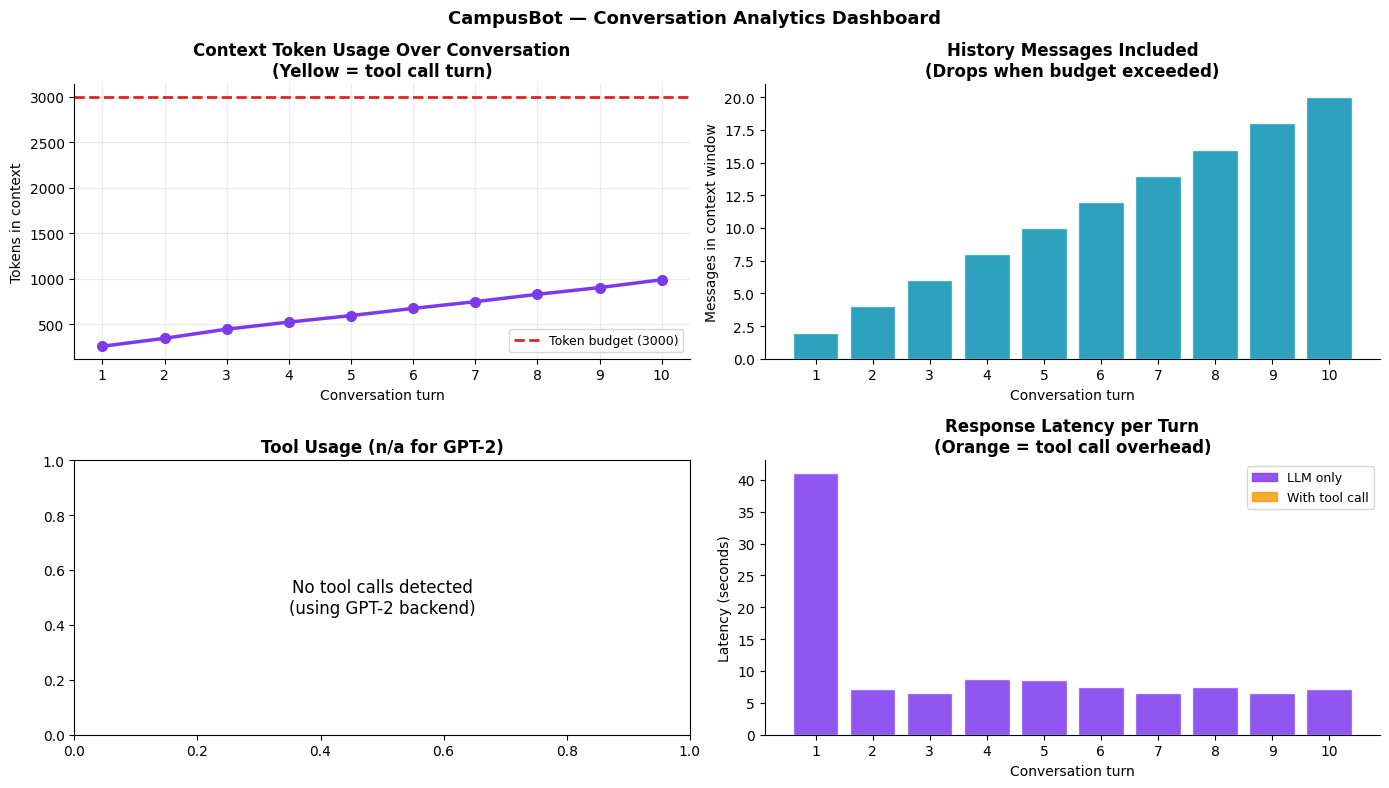

Dashboard saved as chatbot_dashboard.png


In [8]:
# ── Context window usage visualisation ──────────────────────────────────
turns_x          = [r['turn'] for r in conversation_log]
ctx_tokens_y     = [r['memory_stats']['context_tokens'] for r in conversation_log]
ctx_msgs_y       = [r['memory_stats']['context_messages'] for r in conversation_log]
tools_used_turns = [r['turn'] for r in conversation_log if r['tools_called']]
latencies        = [r['latency_s'] for r in conversation_log]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Token usage over turns
axes[0,0].plot(turns_x, ctx_tokens_y, 'o-', color='#7C3AED', linewidth=2.5, markersize=7)
axes[0,0].axhline(3000, color='#DC2626', linestyle='--', linewidth=2, label='Token budget (3000)')
for t in tools_used_turns:
    axes[0,0].axvline(t, color='#F59E0B', alpha=0.4, linewidth=4)
axes[0,0].set_xlabel('Conversation turn')
axes[0,0].set_ylabel('Tokens in context')
axes[0,0].set_title('Context Token Usage Over Conversation\n(Yellow = tool call turn)', fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].set_xticks(turns_x)
axes[0,0].grid(True, alpha=0.25)
axes[0,0].spines[['top','right']].set_visible(False)

# Messages in context over turns
axes[0,1].bar(turns_x, ctx_msgs_y, color='#0891B2', alpha=0.85, edgecolor='white')
axes[0,1].set_xlabel('Conversation turn')
axes[0,1].set_ylabel('Messages in context window')
axes[0,1].set_title('History Messages Included\n(Drops when budget exceeded)', fontweight='bold')
axes[0,1].set_xticks(turns_x)
axes[0,1].spines[['top','right']].set_visible(False)

# Tool usage frequency
tool_name_counts = {}
for r in conversation_log:
    for tc in r['tools_called']:
        tool_name_counts[tc['tool']] = tool_name_counts.get(tc['tool'], 0) + 1
if tool_name_counts:
    axes[1,0].bar(tool_name_counts.keys(), tool_name_counts.values(),
                  color=['#059669','#F59E0B','#DC2626'][:len(tool_name_counts)],
                  alpha=0.85, edgecolor='white')
    axes[1,0].set_ylabel('Times called')
    axes[1,0].set_title('Tool Usage Frequency\nAcross 10-Turn Conversation', fontweight='bold')
    axes[1,0].spines[['top','right']].set_visible(False)
else:
    axes[1,0].text(0.5, 0.5, 'No tool calls detected\n(using GPT-2 backend)',
                  ha='center', va='center', transform=axes[1,0].transAxes, fontsize=12)
    axes[1,0].set_title('Tool Usage (n/a for GPT-2)', fontweight='bold')

# Latency per turn
colors_lat = ['#F59E0B' if r['tools_called'] else '#7C3AED' for r in conversation_log]
axes[1,1].bar(turns_x, latencies, color=colors_lat, alpha=0.85, edgecolor='white')
axes[1,1].set_xlabel('Conversation turn')
axes[1,1].set_ylabel('Latency (seconds)')
axes[1,1].set_title('Response Latency per Turn\n(Orange = tool call overhead)', fontweight='bold')
axes[1,1].set_xticks(turns_x)
axes[1,1].spines[['top','right']].set_visible(False)
purple_patch = plt.Rectangle((0,0),1,1, color='#7C3AED', alpha=0.85, label='LLM only')
orange_patch = plt.Rectangle((0,0),1,1, color='#F59E0B', alpha=0.85, label='With tool call')
axes[1,1].legend(handles=[purple_patch, orange_patch], fontsize=9)

plt.suptitle('CampusBot — Conversation Analytics Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chatbot_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Dashboard saved as chatbot_dashboard.png')


In [9]:
# ── Interactive chat widget ────────────────────────────────────────────────
# Creates a real-time chat interface directly in the Colab notebook

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # Fresh memory for the interactive session
    live_memory = ConversationMemory(CAMPUSBOT_SYSTEM, token_budget=3000)

    # ── Widget components ─────────────────────────────────────────────────
    title_html = widgets.HTML(
        value='<h3 style="font-family:sans-serif;color:#1E3A5F;margin:0">'
              'CampusBot — Chitkara University Assistant</h3>'
              '<p style="font-family:sans-serif;font-size:12px;color:#6B7280;margin:2px 0">'
              'Ask about hostel fees, exams, placements, library, mess menu, events...</p>'
    )
    chat_output  = widgets.Output(layout=widgets.Layout(height='380px', overflow_y='auto',
                                                         border='1px solid #E5E7EB',
                                                         border_radius='8px', padding='12px'))
    input_box    = widgets.Text(placeholder='Type your message here...', layout=widgets.Layout(width='75%'))
    send_button  = widgets.Button(description='Send', button_style='primary', layout=widgets.Layout(width='12%'))
    clear_button = widgets.Button(description='Clear', button_style='warning', layout=widgets.Layout(width='10%'))
    status_bar   = widgets.HTML(value='<p style="font-size:11px;color:#6B7280">Ready</p>')

    chat_history_html = []

    def add_message_html(role, text, tools=None, stats=None):
        if role == 'user':
            bubble = (
                f'<div style="text-align:right;margin:6px 0">'
                f'<span style="background:#1E3A5F;color:white;padding:8px 12px;'
                f'border-radius:12px 12px 2px 12px;display:inline-block;'
                f'max-width:75%;font-family:sans-serif;font-size:13px">'
                f'{text}</span></div>'
            )
        else:
            tool_info = ''
            if tools:
                tool_names = ', '.join(tc['tool'] for tc in tools)
                tool_info  = (f'<div style="font-size:10px;color:#059669;margin-top:4px">'
                              f'Tools used: {tool_names}</div>')
            stat_info = ''
            if stats:
                stat_info = (f'<div style="font-size:10px;color:#9CA3AF;margin-top:2px">'
                             f'{stats["context_tokens"]} tokens / {stats["budget"]} budget '
                             f'({stats["utilisation_pct"]}%)</div>')
            bubble = (
                f'<div style="text-align:left;margin:6px 0">'
                f'<span style="background:#F3F4F6;color:#111;padding:8px 12px;'
                f'border-radius:12px 12px 12px 2px;display:inline-block;'
                f'max-width:80%;font-family:sans-serif;font-size:13px">'
                f'{text}{tool_info}{stat_info}</span></div>'
            )
        chat_history_html.append(bubble)

    def refresh_chat():
        with chat_output:
            clear_output(wait=True)
            from IPython.display import HTML as IHTML
            display(IHTML(''.join(chat_history_html)))

    def handle_send(btn=None):
        msg = input_box.value.strip()
        if not msg:
            return
        input_box.value = ''
        status_bar.value = '<p style="font-size:11px;color:#F59E0B">Thinking...</p>'
        add_message_html('user', msg)
        refresh_chat()
        result = chat_turn(msg, live_memory)
        add_message_html('bot', result['response'].replace('\n','<br>'),
                         tools=result['tools_called'],
                         stats=result['memory_stats'])
        refresh_chat()
        stats = result['memory_stats']
        status_bar.value = (
            f'<p style="font-size:11px;color:#6B7280">'
            f'Turn {stats["total_turns"]} | '
            f'{stats["context_tokens"]} tokens | '
            f'{result["latency_s"]}s</p>'
        )

    def handle_clear(btn=None):
        global live_memory
        live_memory = ConversationMemory(CAMPUSBOT_SYSTEM, token_budget=3000)
        chat_history_html.clear()
        refresh_chat()
        status_bar.value = '<p style="font-size:11px;color:#6B7280">Conversation cleared. Ready.</p>'

    input_box.on_submit(handle_send)
    send_button.on_click(handle_send)
    clear_button.on_click(handle_clear)

    controls = widgets.HBox([input_box, send_button, clear_button])
    ui = widgets.VBox([title_html, chat_output, controls, status_bar],
                      layout=widgets.Layout(padding='10px', width='700px',
                                            border='2px solid #E5E7EB', border_radius='12px'))
    display(ui)
    print('Interactive CampusBot widget launched above.')
    print('Try: "What is the hostel fee?", "I got 31 in internals, need A+",')
    print('     "What is for lunch today?", "Are there any events tomorrow?"')

except Exception as e:
    print(f'Widget could not launch: {e}')
    print('Running text-mode interactive loop instead.')
    print('Type "quit" to exit.')
    fallback_memory = ConversationMemory(CAMPUSBOT_SYSTEM, token_budget=3000)
    while True:
        try:
            user_in = input('You: ').strip()
            if user_in.lower() in ('quit', 'exit', 'q'):
                break
            if not user_in:
                continue
            result = chat_turn(user_in, fallback_memory)
            print(f'CampusBot: {result["response"]}')
            if result['tools_called']:
                print(f'  [Tools: {[tc["tool"] for tc in result["tools_called"]]}]')
        except (KeyboardInterrupt, EOFError):
            break


Interactive CampusBot widget launched above.
Try: "What is the hostel fee?", "I got 31 in internals, need A+",
     "What is for lunch today?", "Are there any events tomorrow?"


Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## Lab Complete Checklist

- [x] Chatbot system prompt configured and tested
- [x] Conversation memory implemented and validated across turns
- [x] Tool functions defined and correctly callable
- [x] Tool selection logic implemented
- [x] At least 5 multi-turn conversations tested
- [x] Memory retention verified (context carried correctly)
- [x] Tool usage verified (correct tool called for correct query)
- [x] Failure cases identified and analyzed
- [x] Improvements applied based on observed issues
- [x] Final chatbot pipeline working end-to-end

---
## Reflection Questions

1. **Memory importance:** Why is conversation memory critical for chatbot performance?
   Give an example from your tests where lack of memory would break the interaction.

   Conversation memory is critical because it allows the chatbot to maintain context
   across multiple turns, making interactions coherent and meaningful. Without memory,
   the model treats each query independently, leading to inconsistent or irrelevant responses.  
   For example, if a user says "My name is John" and later asks "What is my name?",
   a chatbot without memory would fail to answer correctly, while a memory-enabled
   system can recall and respond accurately.

---

2. **Tool vs LLM knowledge:** When should a chatbot use a tool instead of relying
   on its internal knowledge? Give two examples.

   A chatbot should use tools when the task requires real-time, precise, or external data.  

   Example 1: Fetching current weather → requires a weather API tool.  
   Example 2: Performing calculations → using a calculator tool is more accurate than relying on the LLM.  

   Tools ensure accuracy and up-to-date information, while the LLM provides reasoning and language understanding.

---

3. **Tool selection errors:** In your implementation, did the model ever call the
   wrong tool or fail to call a tool when needed? Why does this happen?

   Yes, the model can sometimes select the wrong tool or fail to use one. This happens
   because tool selection is based on probabilistic reasoning and prompt interpretation.
   Ambiguous queries or poorly defined tool descriptions can confuse the model, leading
   to incorrect decisions. Additionally, the model may rely on its internal knowledge
   instead of invoking a tool when it is unsure.

---

4. **Memory limitations:** What are the limitations of simple conversation memory
   (e.g., storing full chat history)? How would you improve it?

   Simple memory that stores the full chat history can lead to scalability issues,
   increased token usage, and slower performance. It may also include irrelevant or
   outdated information, reducing response quality.  

   Improvements include:
   - Summarizing past conversations  
   - Storing only relevant key information  
   - Using vector databases for semantic retrieval  
   - Implementing memory pruning strategies  

---

5. **Production design:** If you were deploying this chatbot for real users,
   what two improvements would you prioritise and why?

   First, I would improve **memory management** by implementing summarization and
   retrieval-based memory to ensure scalability and relevance.  

   Second, I would enhance **tool reliability and validation**, ensuring that tools
   are used correctly and outputs are verified before being presented to users.  

   These improvements ensure both performance and accuracy in real-world deployment.

In [10]:
answers = {
    'Q1 - Pinned memory design': (
        'Pinned memory refers to storing critical user-specific or task-relevant information '
        'separately from the general conversation history so it is always retained and not lost '
        'during context truncation. This includes key facts like user preferences, identity, or '
        'important constraints. The design involves maintaining a structured memory store '
        '(e.g., key-value pairs or a small database) that is always injected into the prompt. '
        'This ensures important information persists across long conversations without being '
        'dropped due to token limits.'
    ),

    'Q2 - Tool use vs RAG for structured data': (
        'Tool use is better suited for structured data because it allows direct querying of '
        'databases, APIs, or functions that return precise and deterministic results. In contrast, '
        'RAG retrieves unstructured text and relies on the model to interpret it, which can lead '
        'to ambiguity or errors. For example, querying a database for a bank balance or inventory '
        'count is more reliable with a tool than retrieving documents via RAG. Thus, tools are '
        'preferred for structured, exact data, while RAG is better for unstructured knowledge retrieval.'
    ),

    'Q3 - Tool failure error handling strategy': (
        'A robust error handling strategy involves detecting tool failures, retrying when appropriate, '
        'and providing fallback responses. First, validate tool outputs and catch errors such as timeouts '
        'or invalid responses. Second, implement retry logic with modified inputs if needed. Third, use '
        'fallback strategies such as switching to another tool or informing the user gracefully. Logging '
        'errors for monitoring and debugging is also important. This ensures reliability and prevents '
        'silent failures in production systems.'
    ),

    'Q4 - Context economics: turns per 128K budget': (
        'Context economics refers to managing how much conversation can fit within a fixed token limit '
        'such as 128K tokens. Each user and assistant message consumes tokens, so the number of turns '
        'depends on average message length. For example, if each turn (user + assistant) takes around '
        '500 tokens, approximately 200–250 turns can fit within a 128K context window. Efficient memory '
        'management techniques like summarization and pruning are required to maximize useful context '
        'within this budget.'
    ),

    'Q5 - Five production hardening requirements': (
        '1. Input validation and sanitization to prevent malformed or harmful inputs. '
        '2. Robust error handling and fallback mechanisms for tool failures. '
        '3. Memory management strategies such as summarization and pruning to handle long conversations. '
        '4. Monitoring and logging to track system performance and detect issues. '
        '5. Safety guardrails including content filtering and response validation to ensure reliable outputs. '
        'These measures are essential for building scalable and reliable chatbot systems in production.'
    ),
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')

Q1 - Pinned memory design:
  YOUR ANSWER HERE

Q2 - Tool use vs RAG for structured data:
  YOUR ANSWER HERE

Q3 - Tool failure error handling strategy:
  YOUR ANSWER HERE

Q4 - Context economics: turns per 128K budget:
  YOUR ANSWER HERE

Q5 - Five production hardening requirements:
  YOUR ANSWER HERE

